# NumPy

NumPy è una delle librerie centrali dell'ecosistema scientifico di Python. Mette a disposizione:

- array multidimensionali veloci e compatti;
- funzioni matematiche vettorializzate;
- strumenti per algebra lineare, numeri casuali e trasformazioni dei dati;
- una base comune su cui lavorano molte altre librerie, tra cui SciPy, pandas e scikit-learn.

Gli array NumPy possono contenere anche tipi definiti dall'utente, quindi la libreria non è limitata ai soli dati numerici. Per approfondire si può consultare la [documentazione ufficiale](https://numpy.org/doc/stable/user/whatisnumpy.html).

In [2]:
import numpy as np  # convenzione comunemente usata per importare NumPy

## Array NumPy: `ndarray`

<p align="center">
  <img src="what-is-numpy.png" alt="Che cos'è NumPy" height="250">
</p>

La classe principale usata da NumPy per rappresentare gli array è `ndarray`, chiamata anche `array`:
```python
a = np.array([1, 2, 3], dtype="float64")
```

<br>

> `numpy.array` è diversa da `array.array` della libreria standard di Python: quest'ultima supporta solo array monodimensionali e offre meno funzionalità.

Gli attributi principali di questa classe sono:

| Attributo  | Descrizione                                                                       |
| ---------- | --------------------------------------------------------------------------------- |
| `ndim`     | Numero di dimensioni, o assi, dell'array.                                         |
| `shape`    | Dimensione dell'array. Per una matrice con `n` righe e `m` colonne vale `(n, m)`. |
| `size`     | Numero totale di elementi presenti nell'array.                                    |
| `dtype`    | Tipo dei dati contenuti, ad esempio `int32` o `float64`.                          |
| `itemsize` | Dimensione in byte di ogni elemento. Un `float64`, ad esempio, occupa 8 byte.     |
| `data`     | Buffer contenente i dati dell'array. Normalmente non viene usato direttamente.    |



Un array NumPy non è una semplice lista Python. È progettato per memorizzare dati omogenei in una struttura regolare e consente di:

- lavorare naturalmente con una o più dimensioni;
- eseguire molte operazioni senza cicli Python espliciti;
- sfruttare una rappresentazione in memoria efficiente;
- scrivere calcoli scientifici in forma compatta.

Per questo motivo, molti programmi numerici sono organizzati attorno alle operazioni sugli array.

Il confronto seguente mostra perché, su grandi quantità di dati, una soluzione vettorializzata con NumPy è spesso più rapida di una list comprehension Python.

In [3]:
# Python standard
L = range(1000)
%timeit [i**2 for i in L]

# NumPy: calcolo vettorializzato
a = np.arange(1000)
%timeit a**2

176 µs ± 43.3 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
611 ns ± 79.3 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


### Tipo di dati contenuti

Un array NumPy è una griglia di valori **dello stesso tipo**. Ogni elemento viene individuato tramite uno o più indici interi non negativi.

NumPy supporta interi con diverse precisioni, numeri in virgola mobile, complessi, booleani e stringhe. L'elenco completo dei tipi è disponibile nella [documentazione](https://numpy.org/doc/stable/user/basics.types.html).

In [ ]:
# Il tipo può essere indicato al momento della creazione
a = np.array([1, 2, 3], dtype="float64")
print(a, a.dtype, "\n")

a = np.array([1, 2, 3], dtype="uint32")
print(a, a.dtype, "\n")

# Se dtype non è specificato, NumPy prova a dedurlo
a = np.array([1, 2, 33])
print(a, a.dtype, "\n")

# Sono ammessi anche i numeri complessi
a = np.array([1 + 2j, 3 + 4j, 5 + 6j])
print(a, a.dtype, "\n")

# Booleani
a = np.array([True, False, False, True])
print(a, a.dtype, "\n")

# Dati non numerici: stringhe
a = np.array(["ciao", "hello", "hallo"])
print(a, a.dtype, "\n")

### Dimensioni, forma e numero di elementi

Il numero di assi di un array è indicato da `ndim`. La proprietà `shape` restituisce invece una tupla con la lunghezza di ciascun asse.

Esempio con un array monodimensionale:

In [ ]:
a1 = np.array([0, 1, 2, 3])
print("array:\n", a1)
print("numero di dimensioni:", a1.ndim)
print("forma:", a1.shape)
print("lunghezza del primo asse:", len(a1))  # poco informativo oltre una dimensione

Esempio con una matrice, cioè un array bidimensionale:

In [ ]:
a2_3 = np.array([[0, 1, 2], [3, 4, 5]])
print("matrice 2 x 3:\n", a2_3)
print("numero di dimensioni:", a2_3.ndim)
print("forma:", a2_3.shape)
print("lunghezza del primo asse:", len(a2_3))

Esempio con un array tridimensionale:

In [ ]:
a2_3_4 = np.array([
    [[1, 10, 100, 1000], [2, 20, 200, 2000], [3, 30, 300, 3000]],
    [[4, 40, 400, 4000], [5, 50, 500, 5000], [6, 60, 600, 6000]]
])
print("array 2 x 3 x 4:\n", a2_3_4)
print("numero di dimensioni:", a2_3_4.ndim)
print("forma:", a2_3_4.shape)
print("lunghezza del primo asse:", len(a2_3_4))

### Creazione degli array

Gli array possono essere costruiti a partire da liste o tuple. È anche possibile riconvertirli in liste con `tolist()`, ma le due strutture restano diverse: un array NumPy conserva un solo tipo di dato e supporta operazioni vettorializzate.

In [ ]:
lista = [0, 1, 2, 3]
array = np.array(lista)
lista_ricostruita = array.tolist()
print(lista_ricostruita, type(lista_ricostruita))

Due strumenti molto usati per generare sequenze numeriche sono:

- `np.arange`, basato su valore iniziale, limite escluso e passo;
- `np.linspace`, basato su estremi e numero desiderato di punti.

In [ ]:
# Valori equidistanti: inizio, limite escluso, passo
print(np.arange(1, 9, 2))

# Numero prefissato di punti, estremi inclusi
print(np.linspace(0, 1, 201))

NumPy offre inoltre funzioni pronte per creare matrici di zeri, di uno, identità, diagonali oppure definite da una funzione.

In [ ]:
# Matrice 3x3 di uno
ones = np.ones((3, 3))
print(ones, "\n")

# Matrice 2x2 di zeri
zeros = np.zeros((2, 2))
print(zeros, "\n")

# Matrice identità 3x3
identita = np.eye(3)
print(identita, "\n")

# Matrice diagonale
diagonale = np.diag(np.array([1, 20, 3, 4]))
print(diagonale, "\n")

# Creazione a partire da una list comprehension
array = np.array([(i, j) for i in range(2) for j in range(3)])
print(array, "\n")

# Valori calcolati da una funzione degli indici
da_funzione = np.fromfunction(
    lambda i, j: (i - 2) ** 2 + (j - i) ** 2,
    (5, 5)
)
print(da_funzione, "\n")

### Modifica della forma e concatenazione

Con `reshape` si può cambiare l'organizzazione degli elementi senza modificarne il numero complessivo. La nuova forma deve quindi essere compatibile con la dimensione dell'array.

In [ ]:
a = np.arange(0, 6)
m = a.reshape(3, 2)
# Una forma incompatibile con il numero di elementi genera un errore.

print("array originale:", a, "\n")
print("array riorganizzato:\n", m, "\n")

a_da_m = m.flatten()
print("ritorno a una dimensione:", a_da_m, "\n")

La concatenazione di array monodimensionali è immediata. Con matrici o tensori bisogna invece specificare l'asse lungo il quale unire i dati.

In [ ]:
# Concatenazione in una dimensione
a = np.array([1, 2])
b = np.array([3, 4, 5, 6])
c = np.array([7, 8, 9])
print("concatenazione 1D:", np.concatenate((a, b, c)), "\n")

# Concatenazione in più dimensioni
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

print("concatenazione predefinita:\n", np.concatenate((a, b)), "\n")
print("lungo l'asse 0:\n", np.concatenate((a, b), axis=0), "\n")
print("lungo l'asse 1:\n", np.concatenate((a, b), axis=1), "\n")

### Riferimenti, viste e copie

Gli array sono oggetti mutabili. Due variabili possono riferirsi agli stessi dati, oppure contenere copie indipendenti.

- un'assegnazione come `b = a` non duplica l'array;
- `a.copy()` crea dati separati;
- alcune operazioni, come molti slicing, producono una **vista** della memoria originale.

In [ ]:
a = np.array([1, 2, 3])
b = a          # stesso oggetto/dati condivisi
c = a.copy()   # copia indipendente

a[0] = 7
print(a, b, c)

b[1] = 7
print(a, b, c)

c[0] = 9
print(a, b, c)

print("a e b condividono memoria?", np.may_share_memory(a, b))
print("a e c condividono memoria?", np.may_share_memory(a, c))

# Verifica: reshape restituisce spesso una vista, quando la disposizione
# in memoria consente di evitare una copia.
d = a.reshape(3, 1)
print("a e d condividono memoria?", np.may_share_memory(a, d))

Con gli array, `id()` non è sufficiente per capire se due oggetti condividono la stessa area di memoria. Per una verifica pratica si può usare `np.may_share_memory()`.

### Indicizzazione

Gli elementi si leggono e si modificano con la sintassi già usata per liste e tuple. Sono validi anche gli indici negativi e gli intervalli nella forma `[inizio:fine:passo]`.

In [ ]:
a = np.arange(10)
print(a[0], a[2], a[-1])

# Sintassi: [inizio:fine:passo].
# Un passo negativo permette di invertire l'ordine.
print(a[2:9:3])
print(a[::-1])

In [ ]:
# Esempio autonomo di indicizzazione, senza immagini esterne
m = np.arange(1, 17).reshape(4, 4)
print("matrice:\n", m)
print("elemento riga 2, colonna 3:", m[1, 2])
print("seconda riga:", m[1])
print("prime due righe, ultime due colonne:\n", m[:2, 2:])

In [ ]:
# Ricostruzione di un semplice array di esempio
esempio = np.arange(1, 13).reshape(3, 4)
print(esempio)

Negli array multidimensionali gli indici vengono forniti come una tupla.

In una matrice:

- il primo indice seleziona la riga;
- il secondo seleziona la colonna;
- un indice incompleto, per esempio `a[0]`, mantiene per intero gli assi non specificati.

### Slicing

Uno slicing individua una porzione dell'array e, normalmente, restituisce una **vista**. Se la vista viene modificata, cambiano anche i dati dell'array originale.

In [ ]:
a = np.diag(np.arange(3))
print(a, "\n")
print(a[1, 1], "\n")
print(a[2], "\n")

# Lo slicing crea una vista
b = a[1:, 1:]
print(b, "\n")

# La modifica della vista si riflette nell'array originale
b[-1, -1] = 10
print(a, "\n")

print("a e b condividono memoria?", np.may_share_memory(a, b))

### Indicizzazione avanzata

Oltre agli slice, NumPy accetta array di booleani e array di interi come indici. Questa tecnica, spesso chiamata *fancy indexing*, produce in genere una **copia** anziché una vista.

In [ ]:
a = np.arange(0, 21, 2)
print("array originale:", a, "\n")

maschera = (a % 3 == 0)
print("maschera:", maschera, "\n")

filtrato = a[maschera]
print("elementi selezionati:", filtrato, "\n")
print("originale e risultato condividono memoria?",
      np.may_share_memory(a, filtrato), "\n")

# La maschera può essere usata anche per assegnare nuovi valori
a[a % 3 == 0] = -1
print("array modificato:", a, "\n")

Un array di indici interi può contenere lo stesso indice più volte e permette di riordinare liberamente gli elementi selezionati.

In [ ]:
a = np.arange(0, 100, 10)
indici = [2, 3, 2, 4, 2]
print("selezione tramite indici:", a[indici], "\n")

La forma del risultato segue la forma dell'array usato come indice.

In [ ]:
a = np.arange(0, 20, 2)
indici = np.array([[3, 4], [9, 7]])
print(a[indici])

In [ ]:
# Esempio di fancy indexing con una matrice
m = np.arange(25).reshape(5, 5)
righe = np.array([0, 2, 4])
colonne = np.array([1, 3, 0])
print("matrice:\n", m)
print("elementi nelle coppie di coordinate:", m[righe, colonne])

## Operazioni con gli array

### Operazioni elemento per elemento

Somma, sottrazione, prodotto, divisione e potenza vengono applicati, salvo indicazioni diverse, separatamente a ogni elemento.

In [ ]:
# Operazioni con scalari
a = np.arange(4)
print(a, "\n")
print(a * 5, "\n")
print(2 ** a, "\n")

In [ ]:
# Operazioni tra array 1D: il calcolo è elemento per elemento
a = np.arange(4)
b = np.ones(4) + 1
print(a, b)
print("a - b:", a - b)
print("a * b:", a * b)

Il simbolo `*` esegue quindi un prodotto elemento per elemento. Per il prodotto matriciale si possono usare `@` oppure `dot()`.

In [ ]:
ones = np.ones((3, 3))
identita = np.eye(3)

print("matrice originale:\n", ones, "\n")
print("prodotto elemento per elemento:\n", ones * identita, "\n")
print("prodotto matriciale:\n", ones @ identita, "\n")

### Altre operazioni

Confronti tra array:

In [ ]:
# Confronti elemento per elemento
print("uguali?:",
      np.array([1, 3, 2, 5]) == np.array([3, 1, 2, 5]))
print("maggiori?:",
      np.array([1, 3, 2, 5]) > np.array([3, 1, 2, 1]))

# Confronto dell'intero array
print(np.array_equal(
    np.array([1, 3, 2, 5]),
    np.array([3, 1, 2, 1])
))

Operazioni logiche tra array booleani:

In [ ]:
a = np.array([1, 1, 0, 0], dtype=bool)
b = np.array([1, 0, 1, 0], dtype=bool)
print("OR logico:", np.logical_or(a, b))
print("AND logico:", np.logical_and(a, b))

Applicazione vettorializzata di funzioni matematiche:

In [ ]:
# Molte funzioni matematiche sono disponibili in forma vettorializzata
a = np.arange(1, 9)
print("seno:", np.sin(a))
print("logaritmo:", np.log(a))

# Le stesse funzioni operano anche su più dimensioni
m = a.reshape(2, 4)
print("esponenziale:\n", np.exp(m))

Operazioni utili sulle matrici:

In [ ]:
# Estrazione degli elementi sopra la diagonale
m = np.arange(16).reshape(4, 4)
print(m)

a = np.triu(m, 1)
print("parte triangolare superiore:\n", a, "\n")
print("trasposta:\n", a.T, "\n")  # a.T è normalmente una vista

NumPy include il modulo `numpy.linalg` per l'algebra lineare. In applicazioni più avanzate si può usare anche `scipy.linalg`, che offre algoritmi aggiuntivi e routine specializzate.

### Riduzioni

Una riduzione combina più elementi e restituisce uno o più valori riassuntivi, per esempio somma, minimo, massimo, media o deviazione standard.

Negli array con più dimensioni, il parametro `axis` stabilisce lungo quale asse eseguire il calcolo.

In [ ]:
a = np.arange(1, 7)
print(a)
print("somma:", a.sum(), np.sum(a))
print("minimo:", a.min(), np.min(a))
print("massimo:", a.max(), np.max(a))
print("indice del minimo:", a.argmin(), np.argmin(a))
print("indice del massimo:", a.argmax(), np.argmax(a))
print("media:", a.mean(), np.mean(a))
print("mediana:", np.median(a))
print("deviazione standard:", a.std(), np.std(a))

In [ ]:
# Le riduzioni funzionano anche in più dimensioni
m = a.reshape(3, 2)
print(m, "\n")

print("somma per colonna:", m.sum(axis=0))
print("somma per riga:", m.sum(axis=1))

### Broadcasting

Le operazioni elemento per elemento richiedono forme compatibili. Il *broadcasting* consente a NumPy di estendere virtualmente gli array più piccoli, senza copiarli esplicitamente, quando le loro dimensioni rispettano precise regole di compatibilità.

In [ ]:
# Broadcasting: un vettore viene esteso virtualmente sulle righe
matrice = np.arange(12).reshape(3, 4)
vettore = np.array([10, 20, 30, 40])

print("matrice:\n", matrice)
print("vettore:", vettore)
print("somma con broadcasting:\n", matrice + vettore)

In [ ]:
a = np.tile(np.arange(0, 40, 10), (3, 1)).T
print("array originale:\n", a, "\n")
print("somma tramite broadcasting:\n", a + np.arange(3), "\n")

### Altre trasformazioni della forma

`np.newaxis` aggiunge un asse di lunghezza uno, mentre `np.resize` costruisce un array della forma richiesta, ripetendo i dati se necessario.

In [ ]:
# Aggiunta di una dimensione
print("nuovo asse in posizione 1:\n",
      np.arange(1, 4)[:, np.newaxis], "\n")
print("nuovo asse in posizione 0:\n",
      np.arange(1, 4)[np.newaxis, :], "\n")

# Ridimensionamento
print("ridimensionamento:\n", np.resize(np.arange(4), (9,)), "\n")

# Numeri pseudocasuali

Per generare campioni casuali si usa spesso `numpy.random`. I numeri sono pseudocasuali: impostando un seme si ottiene la stessa sequenza a ogni esecuzione, caratteristica utile per rendere riproducibili gli esperimenti.

Per analisi statistiche più complete, come densità, quantili e test, si può ricorrere anche a `scipy.stats`.

In [4]:
import numpy.random as npr
npr.seed(123)  # seme fisso per ottenere risultati riproducibili

### Generazione di dati casuali

In [5]:
# Valori uniformi nell'intervallo [0, 1)
print("uniforme:\n", npr.rand(3, 4), "\n")

# Valori da una normale standard
print("normale:\n", npr.randn(2, 5), "\n")

# Interi casuali tra limite inferiore incluso e superiore escluso
print("interi:\n", npr.randint(1, 50, size=(3, 6)), "\n")

uniforme:
 [[0.69646919 0.28613933 0.22685145 0.55131477]
 [0.71946897 0.42310646 0.9807642  0.68482974]
 [0.4809319  0.39211752 0.34317802 0.72904971]] 

normale:
 [[-0.67888615 -0.09470897  1.49138963 -0.638902   -0.44398196]
 [-0.43435128  2.20593008  2.18678609  1.0040539   0.3861864 ]] 

interi:
 [[42 36 29 39 34 22]
 [31 28 35 34 13 41]
 [ 4 43  6  1 12 35]] 



### Campionamento e permutazioni

In [ ]:
# Mescolamento in-place di un vettore
x = np.arange(10)
npr.shuffle(x)
print("vettore mescolato:\n", x, "\n")

# Campione senza reinserimento
x = np.arange(10, 20)
print("scelta senza reinserimento:\n",
      npr.choice(x, 10, replace=False), "\n")

# Campione con reinserimento
print("scelta con reinserimento:\n",
      npr.choice(x, (5, 10), replace=True), "\n")

## Distribuzioni di probabilità

Il modulo casuale di NumPy permette di campionare da numerose distribuzioni, tra cui uniforme, normale, esponenziale, binomiale e multinomiale.

In [ ]:
# Distribuzione esponenziale
print("campione esponenziale:\n",
      npr.exponential(10, size=(3, 2)), "\n")

In [ ]:
# Simulazione di lanci di un dado
probabilita = 1 / 6
frequenze = npr.multinomial(20000, [probabilita] * 6, size=2)
print("frequenze delle sei facce per due giocatori:\n", frequenze)

In [ ]:
# Stima Monte Carlo di pi greco
n = int(1e6)
punti = npr.uniform(-1, 1, (n, 2))
stima_pi = 4.0 * np.sum(
    punti[:, 0] ** 2 + punti[:, 1] ** 2 < 1
) / n
stima_pi

## NumPy Histograms
La funzione `numpy.histogram`, applicata a un array, restituisce due vettori:

* le frequenze dell’istogramma;
* i valori che definiscono i bordi degli intervalli (*bin*).

Anche Matplotlib possiede una funzione per creare istogrammi, chiamata `hist`, simile a quella di Matlab.

La differenza principale è che `matplotlib.pyplot.hist` calcola e visualizza automaticamente l’istogramma, mentre `numpy.histogram` calcola solamente i dati, senza creare il grafico.


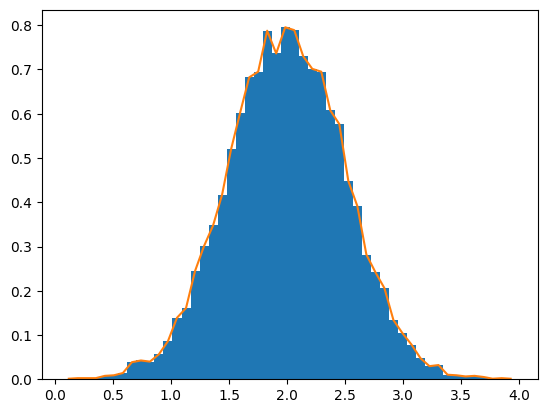

In [1]:
import numpy as np
rg = np.random.default_rng(1)
import matplotlib.pyplot as plt

# Build a vector of 10000 normal deviates with variance 0.5^2 and mean 2
mu, sigma = 2, 0.5
v = rg.normal(mu, sigma, 10000)
# Plot a normalized histogram with 50 bins
plt.hist(v, bins=50, density=True)       # matplotlib version (plot)
# Compute the histogram with numpy and then plot it
(n, bins) = np.histogram(v, bins=50, density=True)  # NumPy version (no plot)
plt.plot(.5 * (bins[1:] + bins[:-1]), n) 